# Scheduling Policy Comparisons

This notebook compares FCFS to non-FCFS scheduling strategies using the same two-class simulation model. The goal here is policy comparison, not the baseline simulation story.

The demand parameterization is fixed across policy comparisons:

- `\lambda` = total expected arrival rate per slot
- `p` = share of class-1 arrivals
- `\lambda_1 = p\lambda`, `\lambda_2 = (1-p)\lambda`

Notation used here:

- `r` is residual delay in the state.
- `\tau` is the original offered delay used in the behavioral functions.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from appointment_simulation import (
    ClassWindowPolicy,
    FCFSPolicy,
    LatestAvailablePolicy,
    PatientClassConfig,
    ReservedCapacityPolicy,
    SimulationConfig,
    green_savin_no_show,
    simulate_replications,
    split_two_class_arrival_rates,
    step_balking,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## Policy comparison setup

All scenarios below use the same patient classes and demand assumptions unless explicitly stated otherwise. Demand is parameterized by a total arrival rate `\lambda` and a fixed class-1 share `p`. The derived class rates shown below are not independent inputs.

For robustness, each policy is evaluated over multiple independent replications of the same booking environment.


In [2]:
BASE_CONFIG = SimulationConfig(
    horizon_days=15,
    slots_per_day=25,
    burn_in_days=250,
    measure_days=1000,
    access_target_days=30,
    rng_seed=7,
)

TOTAL_LAMBDA = 0.24
P = 7 / 12
POLICY_REPLICATIONS = 30


def make_classes(total_lambda=TOTAL_LAMBDA, class_1_share=P, balk_variant="baseline"):
    lambda_1, lambda_2 = split_two_class_arrival_rates(total_lambda, class_1_share)

    if balk_variant == "baseline":
        balk_1 = step_balking(threshold=4, low_delay_probability=0.05, high_delay_probability=0.60)
        balk_2 = step_balking(threshold=3, low_delay_probability=0.08, high_delay_probability=0.70)
    else:
        balk_1 = step_balking(threshold=2, low_delay_probability=0.10, high_delay_probability=0.85)
        balk_2 = step_balking(threshold=2, low_delay_probability=0.12, high_delay_probability=0.90)

    return [
        PatientClassConfig(
            class_id=1,
            label="class_1 (MRI-like)",
            arrival_rate=lambda_1,
            balk_probability=balk_1,
            cancel_probability=0.10,
            no_show_probability=green_savin_no_show(gamma_0=0.01, gamma_max=0.31, sensitivity=50.0),
        ),
        PatientClassConfig(
            class_id=2,
            label="class_2 (mental-health-like)",
            arrival_rate=lambda_2,
            balk_probability=balk_2,
            cancel_probability=0.06,
            no_show_probability=green_savin_no_show(gamma_0=0.15, gamma_max=0.51, sensitivity=9.0),
        ),
    ]

lambda_1, lambda_2 = split_two_class_arrival_rates(TOTAL_LAMBDA, P)
pd.DataFrame(
    [
        {
            "lambda_total": TOTAL_LAMBDA,
            "p": P,
            "lambda_1_derived": lambda_1,
            "lambda_2_derived": lambda_2,
            "horizon_days": BASE_CONFIG.horizon_days,
            "slots_per_day": BASE_CONFIG.slots_per_day,
            "policy_replications": POLICY_REPLICATIONS,
        }
    ]
)


,lambda_total,p,lambda_1_derived,lambda_2_derived,horizon_days,slots_per_day,policy_replications
0,0.24,0.583333,0.14,0.1,15,25,30


## Policy comparison

The notebook compares FCFS to latest-available placement, reserved-capacity protection, class-specific windows, and a stricter balking scenario.

In [3]:
comparison_rows = []
class_rows = []
comparison_setups = [
    ("FCFS baseline", FCFSPolicy(), make_classes()),
    ("Latest-slot policy", LatestAvailablePolicy(), make_classes()),
    (
        "Reserved-capacity policy",
        ReservedCapacityPolicy.from_shares(
            slots_per_day=BASE_CONFIG.slots_per_day,
            reserved_share_by_class={1: 0.20, 2: 0.20},
        ),
        make_classes(),
    ),
    ("Class-window policy", ClassWindowPolicy(max_delay_by_class={1: 4, 2: 8}), make_classes()),
    ("Stricter step balking", FCFSPolicy(), make_classes(balk_variant="strict")),
]

for setup_index, (name, policy, classes) in enumerate(comparison_setups):
    results = simulate_replications(
        class_configs=classes,
        config=BASE_CONFIG,
        policy=policy,
        replications=POLICY_REPLICATIONS,
        base_seed=10_000 + setup_index * POLICY_REPLICATIONS,
    )
    for replication, result in enumerate(results):
        comparison_rows.append(
            {
                "setup": name,
                "policy": result.policy_name,
                "replication": replication,
                "aggregate_mean_delay": result.summary_aggregate["mean_delay_booked"],
                "booked_within_access_target_per_arrival": result.summary_aggregate[
                    "booked_within_access_target_per_arrival"
                ],
                "served_per_booked": result.summary_aggregate["served_per_booked"],
                "booked_slot_utilization": result.slot_summary_aggregate["booked_slot_utilization"],
                "attended_slot_utilization": result.slot_summary_aggregate["attended_slot_utilization"],
            }
        )

        frame = result.summary_by_class[
            ["class_id", "label", "mean_delay_booked", "booked_within_access_target_per_arrival", "served_per_booked"]
        ].copy()
        frame["setup"] = name
        frame["replication"] = replication
        class_rows.append(frame)

comparison_df = pd.DataFrame(comparison_rows).sort_values(["setup", "replication"])
class_comparison_df = pd.concat(class_rows, ignore_index=True)

comparison_summary = (
    comparison_df.groupby("setup")
    .agg(
        replications=("replication", "nunique"),
        mean_delay_mean=("aggregate_mean_delay", "mean"),
        mean_delay_sd=("aggregate_mean_delay", "std"),
        served_per_booked_mean=("served_per_booked", "mean"),
        served_per_booked_sd=("served_per_booked", "std"),
    )
    .sort_index()
)

comparison_summary


,replications,mean_delay_mean,mean_delay_sd,served_per_booked_mean,served_per_booked_sd
setup,,,,,
Class-window policy,30,0.046491,0.002498,0.927234,0.003374
FCFS baseline,30,0.045383,0.002752,0.927822,0.003090
Latest-slot policy,30,14.000000,0.000000,0.724415,0.008294
Reserved-capacity policy,30,0.243492,0.005472,0.909588,0.004367
Stricter step balking,30,0.046595,0.002637,0.927446,0.003722


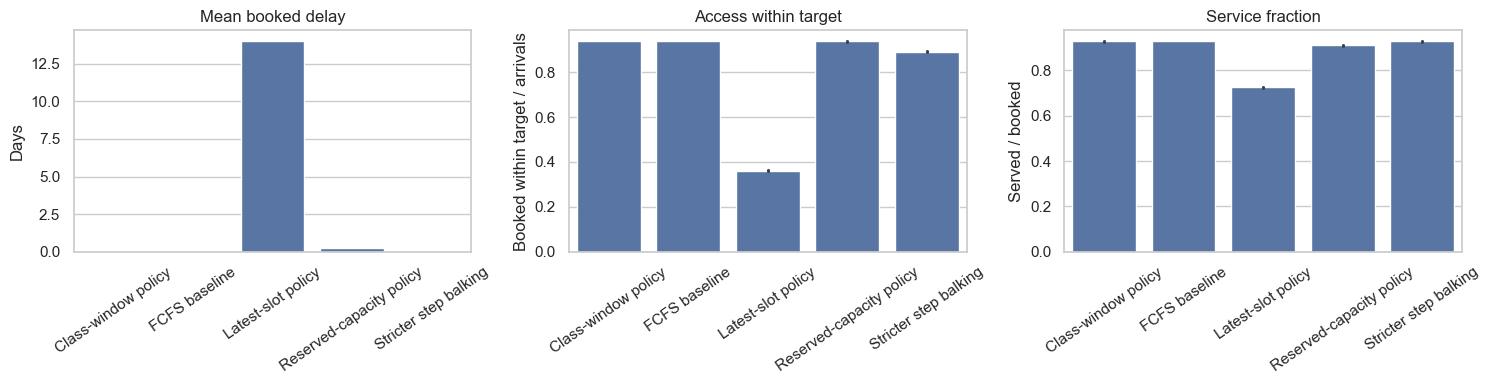

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=comparison_df, x="setup", y="aggregate_mean_delay", errorbar=("ci", 95), ax=axes[0])
axes[0].set_title("Mean booked delay")
axes[0].set_xlabel("")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=comparison_df,
    x="setup",
    y="booked_within_access_target_per_arrival",
    errorbar=("ci", 95),
    ax=axes[1],
)
axes[1].set_title("Access within target")
axes[1].set_xlabel("")
axes[1].set_ylabel("Booked within target / arrivals")
axes[1].tick_params(axis="x", rotation=35)

sns.barplot(data=comparison_df, x="setup", y="served_per_booked", errorbar=("ci", 95), ax=axes[2])
axes[2].set_title("Service fraction")
axes[2].set_xlabel("")
axes[2].set_ylabel("Served / booked")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()


In [5]:
class_comparison_summary = (
    class_comparison_df.groupby(["setup", "label"])
    .agg(
        replications=("replication", "nunique"),
        mean_delay_mean=("mean_delay_booked", "mean"),
        mean_delay_sd=("mean_delay_booked", "std"),
        access_mean=("booked_within_access_target_per_arrival", "mean"),
        access_sd=("booked_within_access_target_per_arrival", "std"),
        served_per_booked_mean=("served_per_booked", "mean"),
        served_per_booked_sd=("served_per_booked", "std"),
    )
    .sort_index()
)

class_comparison_summary


replications  \
setup                    label                                        
Class-window policy      class_1 (MRI-like)                      30   
                         class_2 (mental-health-like)            30   
FCFS baseline            class_1 (MRI-like)                      30   
                         class_2 (mental-health-like)            30   
Latest-slot policy       class_1 (MRI-like)                      30   
                         class_2 (mental-health-like)            30   
Reserved-capacity policy class_1 (MRI-like)                      30   
                         class_2 (mental-health-like)            30   
Stricter step balking    class_1 (MRI-like)                      30   
                         class_2 (mental-health-like)            30   

                                                       mean_delay_mean  \
setup                    label                                           
Class-window policy      class_1 (MRI-like)                   0.046113   
                         class_2 (mental-health-like)         0.047021   
FCFS baseline            class_1 (MRI-like)                   0.045693   
                         class_2 (mental-health-like)         0.044970   
Latest-slot policy       class_1 (MRI-like)                  14.000000   
                         class_2 (mental-health-like)        14.000000   
Reserved-capacity policy class_1 (MRI-like)                   0.243921   
                         class_2 (mental-health-like)         0.242826   
Stricter step balking    class_1 (MRI-like)                   0.045903   
                         class_2 (mental-health-like)         0.047564   

                                                       mean_delay_sd  \
setup                    label                                         
Class-window policy      class_1 (MRI-like)                 0.003964   
                         class_2 (mental-health-like)       0.003978   
FCFS baseline            class_1 (MRI-like)                 0.003975   
                         class_2 (mental-health-like)       0.004258   
Latest-slot policy       class_1 (MRI-like)                 0.000000   
                         class_2 (mental-health-like)       0.000000   
Reserved-capacity policy class_1 (MRI-like)                 0.008109   
                         class_2 (mental-health-like)       0.007727   
Stricter step balking    class_1 (MRI-like)                 0.004071   
                         class_2 (mental-health-like)       0.004031   

                                                       access_mean  access_sd  \
setup                    label                                                  
Class-window policy      class_1 (MRI-like)               0.949953   0.003511   
                         class_2 (mental-health-like)     0.920050   0.004201   
FCFS baseline            class_1 (MRI-like)               0.949195   0.004320   
                         class_2 (mental-health-like)     0.921626   0.004285   
Latest-slot policy       class_1 (MRI-like)               0.402272   0.008265   
                         class_2 (mental-health-like)     0.302292   0.008708   
Reserved-capacity policy class_1 (MRI-like)               0.949911   0.003906   
                         class_2 (mental-health-like)     0.920064   0.006093   
Stricter step balking    class_1 (MRI-like)               0.899143   0.003726   
                         class_2 (mental-health-like)     0.881234   0.006854   

                                                       served_per_booked_mean  \
setup                    label                                                  
Class-window policy      class_1 (MRI-like)                          0.985237   
                         class_2 (mental-health-like)                0.843948   
FCFS baseline            class_1 (MRI-like)                          0.985158   
                         class_2 (mental-health-like)                0